<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Stochastic-Simulations/blob/master/Zadanie_2_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

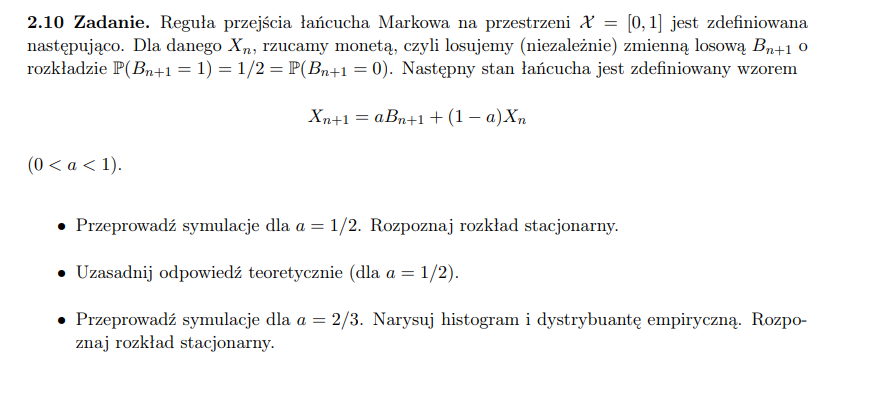

### Simulations
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def sampler(n=100, x0=0, a=0.5):
  trajectory = [x0]
  u = np.random.rand(n)
  for i in range(n):
    b = 1 if u[i]<0.5 else 0
    trajectory.append(a*b+(1-a)*trajectory[-1])
  return trajectory

In [4]:
trajectory = sampler(n=1000000, x0=0.5, a=0.5)
trajectory_burnout = trajectory[1000:]

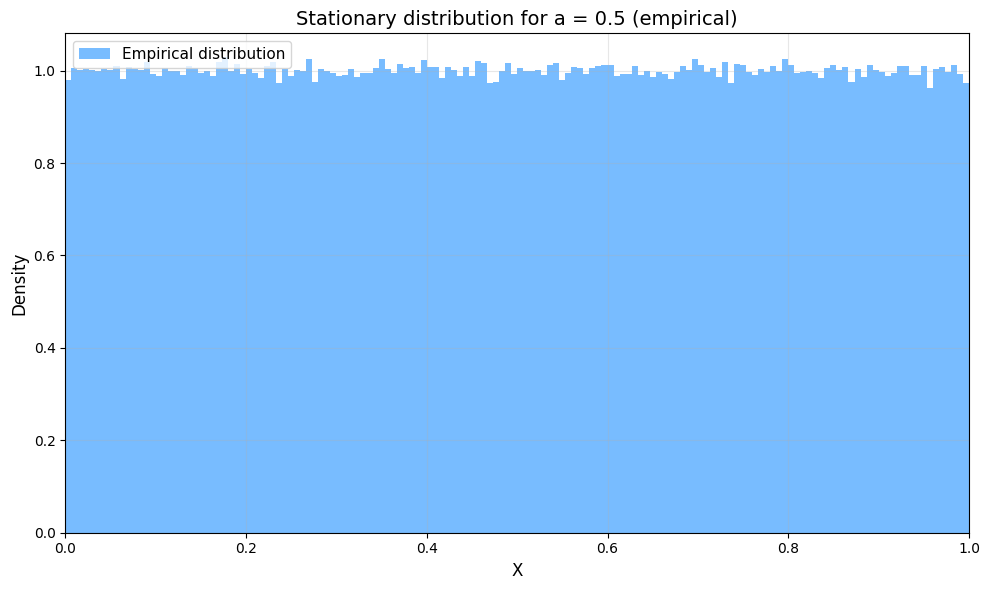

In [6]:
plt.figure(figsize=(10, 6))

plt.hist(trajectory_burnout, bins=150, density=True, alpha=0.6, color='dodgerblue',
         label='Empirical distribution')


plt.title(f'Stationary distribution for a = 0.5 (empirical)', fontsize=14)
plt.xlabel('X', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 1)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Stationary distribution (theoretical)
---

$$X_{n+1} = \frac{1}{2} B_{n+1} + \frac{1}{2} X_n$$

Let us write a few first random variables $X_i$:

$$X_1 = \frac{B_1}{2} + \frac{X_0}{2}$$
$$X_2 = \frac{B_2}{2} + \frac{X_1}{2} = \frac{B_2}{2} + \frac{B_1}{4} + \frac{X_0}{4}$$
$$X_3 = \frac{B_3}{2} + \frac{B_2}{4} + \frac{B_1}{8} + \frac{X_0}{8}$$

We can observe that:

$$X_n = \sum_{k=1}^n \frac{B_{n-k+1}}{2^k} + \frac{X_0}{2^n},$$

(it can also be proved by easy induction).

When $n \rightarrow \infty$, $X_0$ vanishes and we obtain:

$$X_\infty = \sum_{k=1}^\infty \frac{B_k}{2^k}$$

Variables $B_k$ take values $0$ or $1$ with probability $1/2$. Now, it's important to notice that $X_\infty$ corresponds exactly to the binary expansion of a number after the radix point. Since each bit of this fractional binary representation is sampled independently with a probability of 1/2, the resulting number uniformly covers the entire interval $[0, 1]$. Therefore, the stationary distribution for $a = 1/2$ is the uniform distribution on the interval $[0, 1]$.


### Simulations for $a=2/3$
---

In [7]:
trajectory = sampler(n=1000000, x0=0.5, a=2/3)
trajectory_burnout = trajectory[1000:]

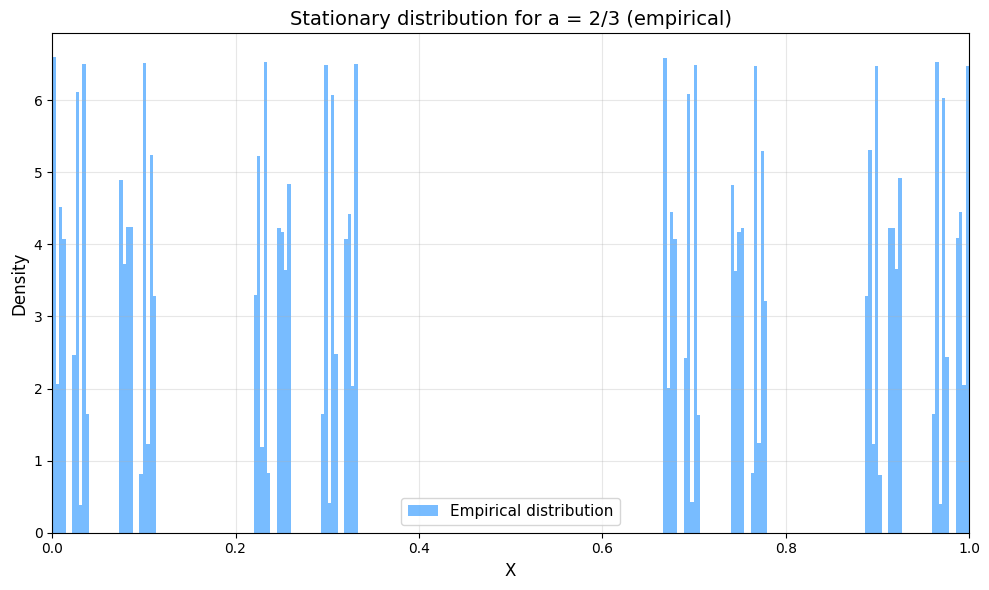

In [13]:
# Cantor Set
plt.figure(figsize=(10, 6))

plt.hist(trajectory_burnout, bins=273, density=True, alpha=0.6, color='dodgerblue',
         label='Empirical distribution')


plt.title(f'Stationary distribution for a = 2/3 (empirical)', fontsize=14)
plt.xlabel('X', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 1)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

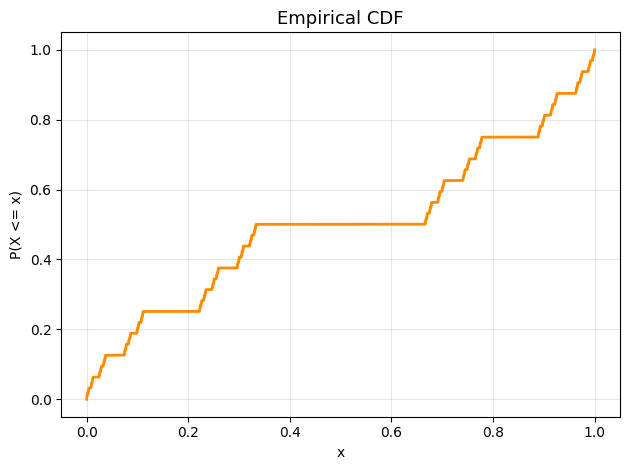

In [15]:
# CDF - Diabelskie Schody - Cantor Function
x_sorted = np.sort(trajectory_burnout)
y_ecdf = np.arange(1, len(x_sorted) + 1) / len(x_sorted)

plt.plot(x_sorted, y_ecdf, color='darkorange', linewidth=2)
plt.title("Empirical CDF", fontsize=13)
plt.xlabel('x')
plt.ylabel('P(X <= x)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()